In [146]:
import sys
from pathlib import Path

ROOT = Path("__file__").resolve().parent.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

LOG_DIR = ROOT / "log"

In [147]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Ellipse

%matplotlib inline
plt.rcParams.update({"figure.dpi": 120, "font.size": 9})

## Available episodes

In [148]:
episode_files = sorted(LOG_DIR.glob("episode_*.h5"))
print(f"Found {len(episode_files)} episode(s) in {LOG_DIR}\n")

for f in episode_files:
    with h5py.File(f, "r") as h:
        n    = h.attrs["n_steps"]
        ok   = bool(h.attrs["success"])
        var  = h.attrs["variant"]
        face = h.attrs["face"]
        print(f"  {f.name:30s}  steps={n:4d}  success={ok}  variant={var}  face={face}")

Found 1 episode(s) in /Users/alex/Workspace/projects/vision_mpc/log

  episode_0000.h5                 steps= 385  success=True  variant=BASELINE  face=None


## Logged signals (inspecting first episode)

In [149]:
with h5py.File(episode_files[0], "r") as h:
    print("=== Attributes ===")
    for k, v in h.attrs.items():
        print(f"  {k:20s}: {v}")

    print("\n=== Datasets ===")
    print(f"  {'name':25s} {'shape':20s} dtype")
    print(f"  {'-'*25} {'-'*20} -----")
    for k in h.keys():
        ds = h[k]
        print(f"  {k:25s} {str(ds.shape):20s} {ds.dtype}")

=== Attributes ===
  face                : None
  goal_theta          : 0.2
  goal_xy             : [0.5 0.1]
  n_steps             : 385
  start_theta         : 0.0
  start_xy            : [ 0.6 -0.1]
  success             : 1
  variant             : BASELINE

=== Datasets ===
  name                      shape                dtype
  ------------------------- -------------------- -----
  control                   (385, 2)             float64
  detection_valid           (385,)               bool
  ee_pos                    (385, 3)             float64
  ee_vel                    (385, 2)             float64
  gt_state                  (385, 3)             float64
  obs_cov                   (385, 3, 3)          float64
  obs_state                 (385, 3)             float64
  p_y                       (385,)               float64
  pusher_tip                (385, 2)             float64
  ref_state                 (385, 4)             float64
  solve_time_ms             (385,)          

## Load helpers

In [150]:
def load_episode(path):
    with h5py.File(path, "r") as h:
        data = {k: h[k][:] for k in h.keys()}
        data["_meta"] = {k: v for k, v in h.attrs.items()}
    return data


def confidence_ellipse(cov2d, ax, pos, n_std=2.0, **kwargs):
    vals, vecs = np.linalg.eigh(cov2d)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    angle = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
    w, h  = 2 * n_std * np.sqrt(np.abs(vals))
    ell   = Ellipse(xy=pos, width=w, height=h, angle=angle, **kwargs)
    ax.add_patch(ell)


def mask_to_segments(t, values, mask):
    """Returns list of (t_seg, val_seg) arrays split on mask=False gaps."""
    segments = []
    in_seg   = False
    for i, valid in enumerate(mask):
        if valid and not in_seg:
            start = i
            in_seg = True
        elif not valid and in_seg:
            segments.append((t[start:i], values[start:i]))
            in_seg = False
    if in_seg:
        segments.append((t[start:], values[start:]))
    return segments

## Select episode to analyse

In [151]:
EPISODE_IDX = 0

ep   = load_episode(episode_files[EPISODE_IDX])
meta = ep["_meta"]
t    = ep["t"]
N    = len(t)
det  = ep["detection_valid"]

det_rate = det.mean() * 100
print(f"Episode {EPISODE_IDX} — variant={meta['variant']}  success={bool(meta['success'])}  steps={N}")
print(f"Detection rate: {det_rate:.1f}%  ({det.sum()} / {N} steps)")

Episode 0 — variant=BASELINE  success=True  steps=385
Detection rate: 73.0%  (281 / 385 steps)


## Slider state: GT vs vision

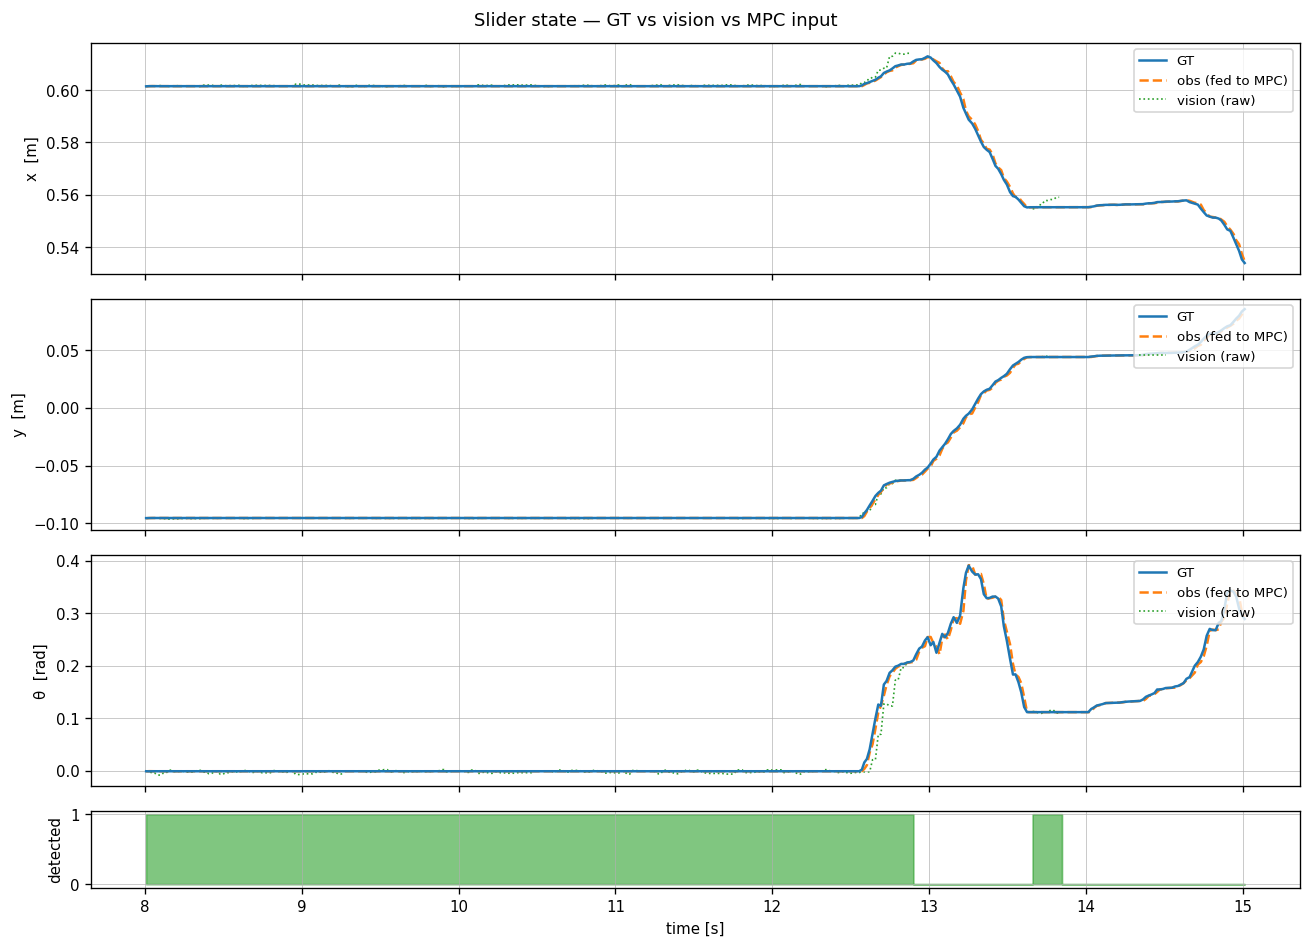

In [ ]:
labels = ["x  [m]", "y  [m]", "θ  [rad]"]

fig, axes = plt.subplots(4, 1, figsize=(11, 8), sharex=True, gridspec_kw={"height_ratios": [3, 3, 3, 1]})

for i, (ax, lbl) in enumerate(zip(axes[:3], labels)):
    ax.plot(t, ep["gt_state"][:, i], lw=1.5, label="GT", zorder=3)
    ax.plot(t, ep["obs_state"][:, i], lw=1.5, ls="--", label="obs (fed to MPC)", zorder=2)
    for t_seg, v_seg in mask_to_segments(t, ep["vis_state"][:, i], det):
        ax.plot(t_seg, v_seg, lw=1.0, ls=":", color="C2", label="vision (raw)" if t_seg[0] == t[det.argmax()] else None, zorder=1)
    ax.set_ylabel(lbl)
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(True, lw=0.4)

axes[3].fill_between(t, det.astype(float), step="post", color="C2", alpha=0.6)
axes[3].set_ylabel("detected")
axes[3].set_yticks([0, 1])
axes[3].set_xlabel("time [s]")
axes[3].grid(True, lw=0.4)

fig.suptitle("Slider state — GT vs vision vs MPC input")
fig.tight_layout()
plt.show()

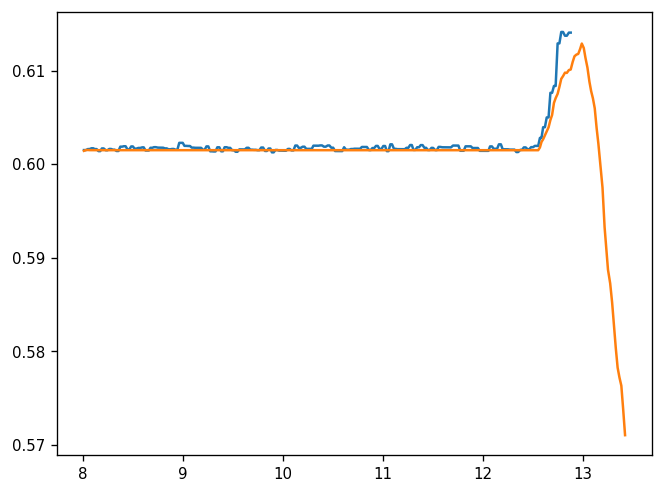

In [ ]:
start, stop = 100, 300
plt.plot(t[start:stop], ep["vis_state"][start:stop, 0])
plt.plot(t[start:stop], ep["gt_state"][start:stop, 0])
plt.show()

## Vision estimation error (detected steps only)

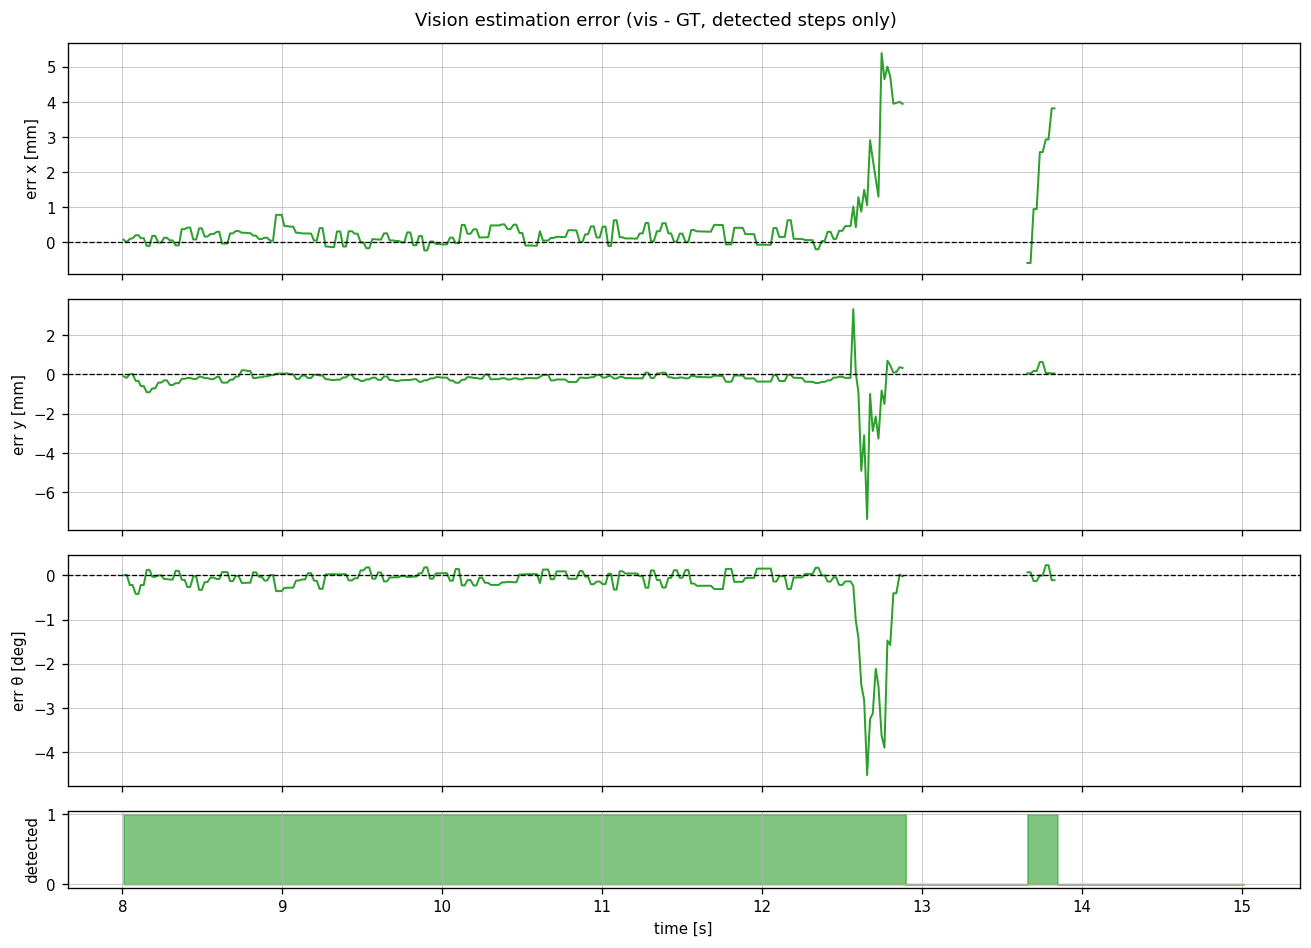

  xy  error — mean 0.64 mm   max 7.44 mm   std 1.03 mm
  θ   error — mean 0.24°   max 4.51°


In [154]:
err = ep["vis_state"] - ep["gt_state"]
err[:, 2] = (err[:, 2] + np.pi) % (2 * np.pi) - np.pi

err_labels = ["err x [mm]", "err y [mm]", "err θ [deg]"]
scales     = [1000, 1000, np.degrees(1)]

fig, axes = plt.subplots(4, 1, figsize=(11, 8), sharex=True,
                         gridspec_kw={"height_ratios": [3, 3, 3, 1]})

for i, (ax, lbl, sc) in enumerate(zip(axes[:3], err_labels, scales)):
    for t_seg, v_seg in mask_to_segments(t, err[:, i] * sc, det):
        ax.plot(t_seg, v_seg, lw=1.2, color="C2")
    ax.axhline(0, lw=0.8, color="k", ls="--")
    ax.set_ylabel(lbl)
    ax.grid(True, lw=0.4)

axes[3].fill_between(t, det.astype(float), step="post", color="C2", alpha=0.6)
axes[3].set_ylabel("detected")
axes[3].set_yticks([0, 1])
axes[3].set_xlabel("time [s]")
axes[3].grid(True, lw=0.4)

fig.suptitle("Vision estimation error (vis - GT, detected steps only)")
fig.tight_layout()
plt.show()

if det.any():
    xy_err_mm = np.linalg.norm(err[det, :2], axis=1) * 1000
    th_err_deg = np.degrees(np.abs(err[det, 2]))
    print(f"  xy  error — mean {xy_err_mm.mean():.2f} mm   max {xy_err_mm.max():.2f} mm   std {xy_err_mm.std():.2f} mm")
    print(f"  θ   error — mean {th_err_deg.mean():.2f}°   max {th_err_deg.max():.2f}°")

## Control inputs

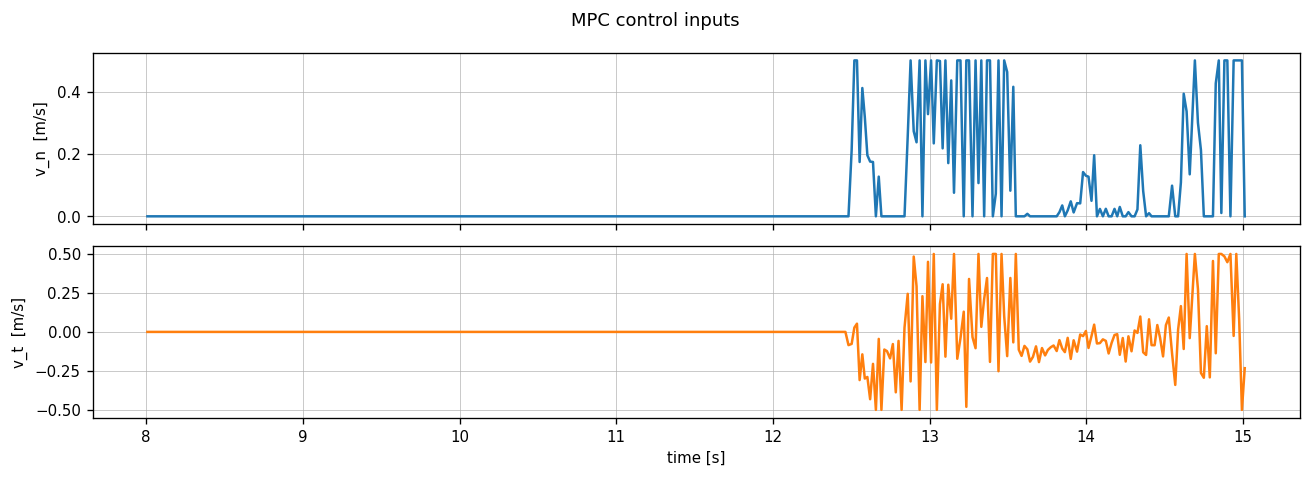

In [155]:
fig, axes = plt.subplots(2, 1, figsize=(11, 4), sharex=True)

axes[0].plot(t, ep["control"][:, 0], lw=1.5, color="C0")
axes[0].set_ylabel("v_n  [m/s]")
axes[0].grid(True, lw=0.4)

axes[1].plot(t, ep["control"][:, 1], lw=1.5, color="C1")
axes[1].set_ylabel("v_t  [m/s]")
axes[1].set_xlabel("time [s]")
axes[1].grid(True, lw=0.4)

fig.suptitle("MPC control inputs")
fig.tight_layout()
plt.show()

## Tracking: reference vs GT

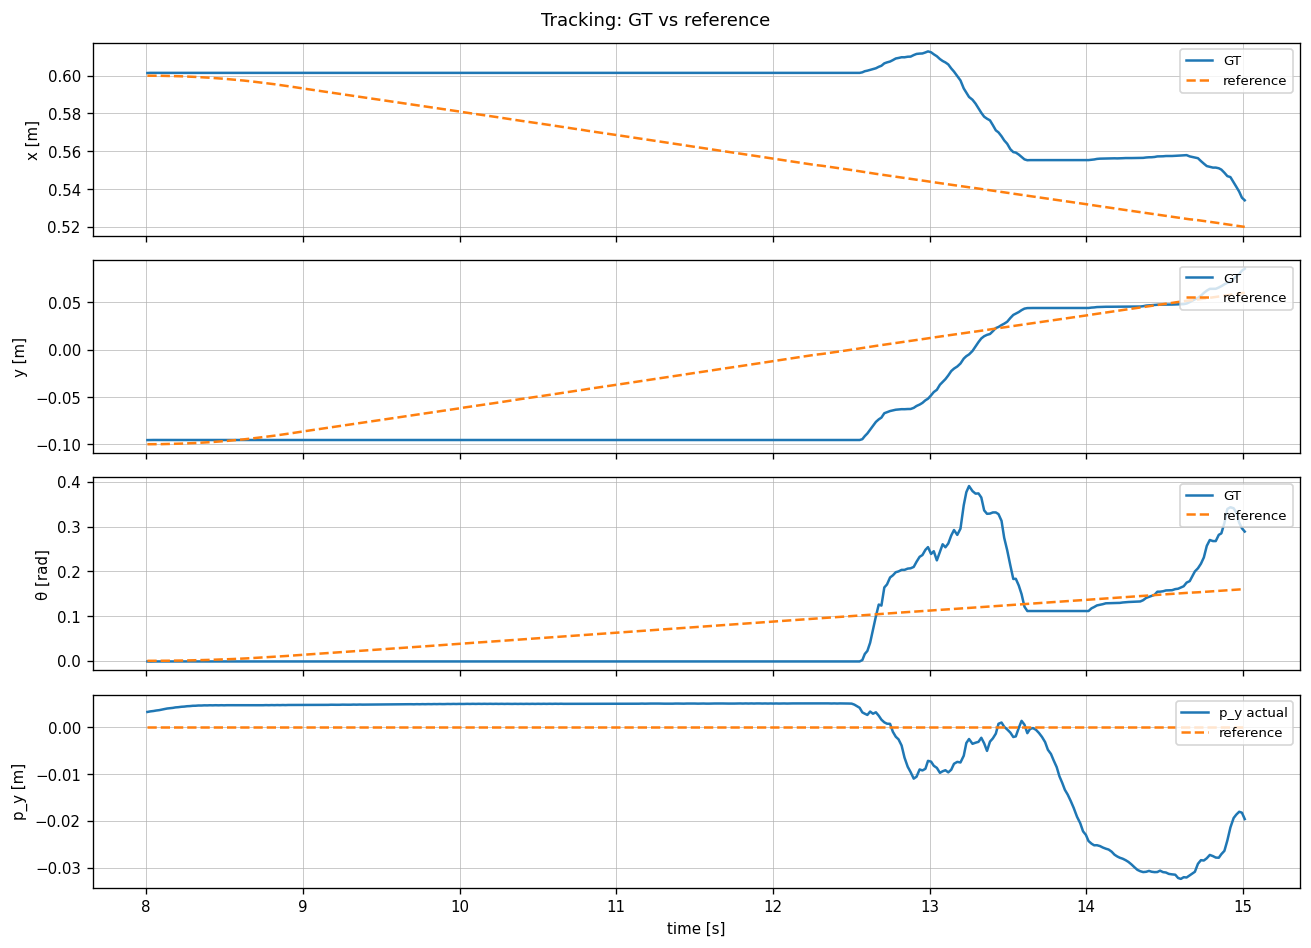

In [156]:
track_labels = ["x [m]", "y [m]", "θ [rad]", "p_y [m]"]

fig, axes = plt.subplots(4, 1, figsize=(11, 8), sharex=True)
for i, (ax, lbl) in enumerate(zip(axes, track_labels)):
    if i < 3:
        ax.plot(t, ep["gt_state"][:, i], lw=1.5, label="GT")
    else:
        ax.plot(t, ep["p_y"], lw=1.5, label="p_y actual")
    ax.plot(t, ep["ref_state"][:, i], lw=1.5, ls="--", label="reference")
    ax.set_ylabel(lbl)
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(True, lw=0.4)

axes[-1].set_xlabel("time [s]")
fig.suptitle("Tracking: GT vs reference")
fig.tight_layout()
plt.show()

## XY trajectory

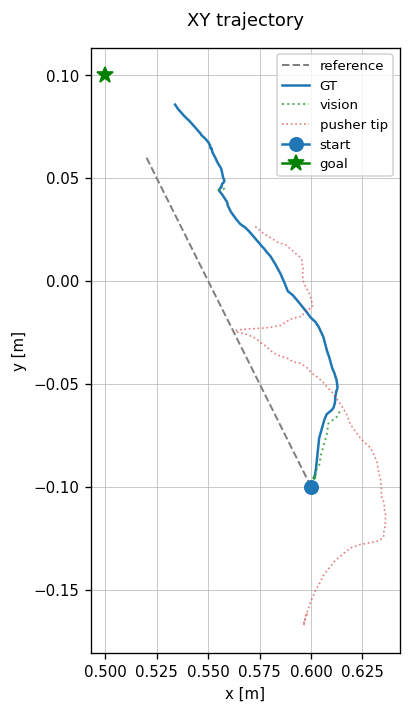

In [157]:
fig, ax = plt.subplots(figsize=(6, 6))

ax.plot(ep["ref_state"][:, 0], ep["ref_state"][:, 1],
        ls="--", lw=1.2, color="grey", label="reference")
ax.plot(ep["gt_state"][:, 0], ep["gt_state"][:, 1],
        lw=1.5, color="C0", label="GT")

for t_seg, _ in mask_to_segments(t, t, det):
    idx = np.searchsorted(t, t_seg)
    ax.plot(ep["vis_state"][idx, 0], ep["vis_state"][idx, 1],
            lw=1.2, color="C2", ls=":", alpha=0.8,
            label="vision" if t_seg[0] == t[det.argmax()] else None)

ax.plot(ep["pusher_tip"][:, 0], ep["pusher_tip"][:, 1],
        lw=1.0, color="C3", ls=":", label="pusher tip", alpha=0.6)

ax.plot(*meta["start_xy"], marker="o", ms=8,  color="C0",   label="start")
ax.plot(*meta["goal_xy"],  marker="*", ms=10, color="green", label="goal")

cov_has_info = np.any(ep["obs_cov"] != 0)
if cov_has_info:
    step = max(1, N // 20)
    for i in range(0, N, step):
        if ep["detection_valid"][i]:
            confidence_ellipse(ep["obs_cov"][i, :2, :2], ax,
                               pos=ep["obs_state"][i, :2],
                               n_std=2, edgecolor="C1", facecolor="none", lw=0.8, alpha=0.5)

ax.set_aspect("equal")
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.legend(fontsize=8)
ax.grid(True, lw=0.4)
fig.suptitle("XY trajectory")
fig.tight_layout()
plt.show()

## Solver performance

  solver failures:  0/385 (0.0%)
  solve time — mean 5.3 ms   max 18.5 ms


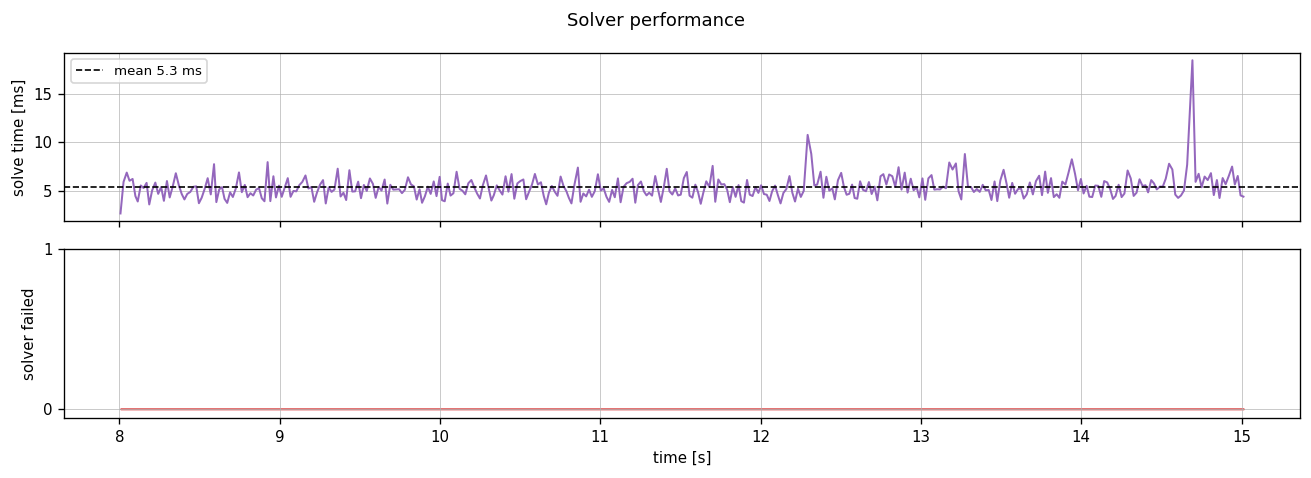

In [158]:
fig, axes = plt.subplots(2, 1, figsize=(11, 4), sharex=True)

axes[0].plot(t, ep["solve_time_ms"], lw=1.2, color="C4")
axes[0].axhline(ep["solve_time_ms"].mean(), ls="--", lw=1.0, color="k",
                label=f'mean {ep["solve_time_ms"].mean():.1f} ms')
axes[0].set_ylabel("solve time [ms]")
axes[0].legend(fontsize=8)
axes[0].grid(True, lw=0.4)

fail_mask = ep["solver_status"] != 0
axes[1].fill_between(t, fail_mask.astype(float), step="post", color="C3", alpha=0.7)
axes[1].set_ylabel("solver failed")
axes[1].set_yticks([0, 1])
axes[1].set_xlabel("time [s]")
axes[1].grid(True, lw=0.4)

n_fails = fail_mask.sum()
print(f"  solver failures:  {n_fails}/{N} ({100*n_fails/N:.1f}%)")
print(f"  solve time — mean {ep['solve_time_ms'].mean():.1f} ms   max {ep['solve_time_ms'].max():.1f} ms")

fig.suptitle("Solver performance")
fig.tight_layout()
plt.show()

## Multi-episode comparison

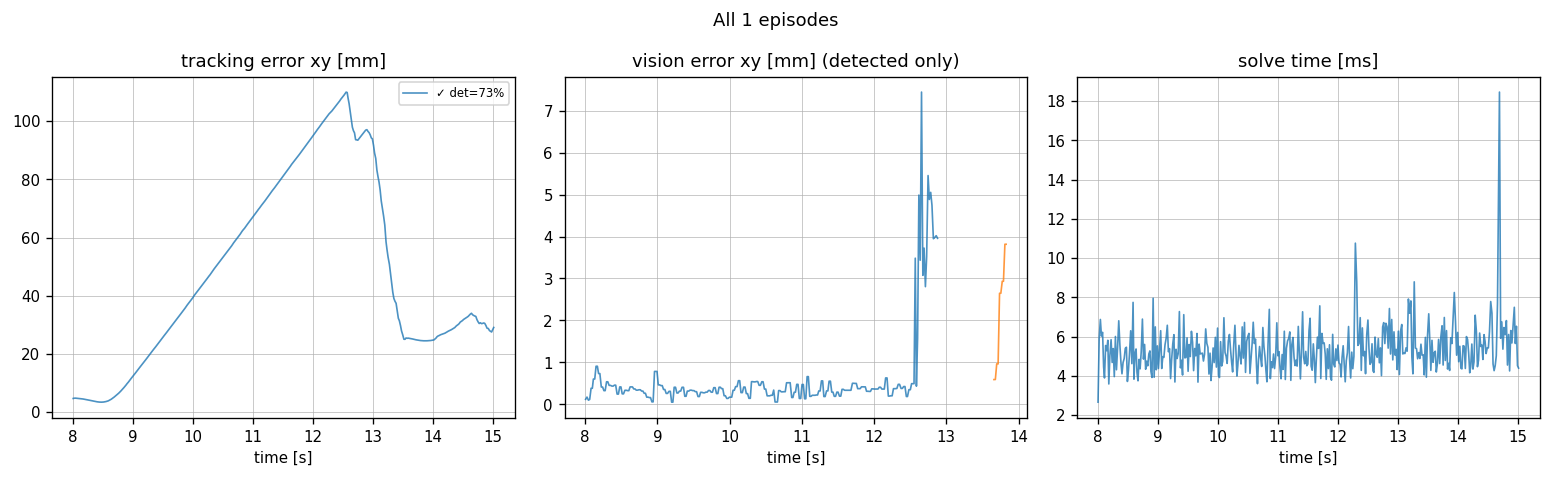

In [159]:
episodes = [load_episode(f) for f in episode_files]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ep_i in episodes:
    t_i   = ep_i["t"]
    det_i = ep_i["detection_valid"]
    err_i = ep_i["vis_state"] - ep_i["gt_state"]
    err_i[:, 2] = (err_i[:, 2] + np.pi) % (2 * np.pi) - np.pi

    pos_err_mm = np.linalg.norm(ep_i["gt_state"][:, :2] - ep_i["ref_state"][:, :2], axis=1) * 1000
    vis_err_mm = np.linalg.norm(err_i[:, :2], axis=1) * 1000
    ok_str     = "✓" if ep_i["_meta"]["success"] else "✗"
    det_rate_i = det_i.mean() * 100
    lbl        = f"{ok_str} det={det_rate_i:.0f}%"

    axes[0].plot(t_i, pos_err_mm, lw=1.0, alpha=0.8, label=lbl)
    for t_seg, v_seg in mask_to_segments(t_i, vis_err_mm, det_i):
        axes[1].plot(t_seg, v_seg, lw=1.0, alpha=0.8)
    axes[2].plot(t_i, ep_i["solve_time_ms"], lw=1.0, alpha=0.8)

axes[0].set_title("tracking error xy [mm]")
axes[0].legend(fontsize=7)
axes[1].set_title("vision error xy [mm] (detected only)")
axes[2].set_title("solve time [ms]")
for ax in axes:
    ax.set_xlabel("time [s]")
    ax.grid(True, lw=0.4)

fig.suptitle(f"All {len(episodes)} episodes")
fig.tight_layout()
plt.show()